# Day 19: Pipelines & Automation in Machine Learning
---

## 📌 Objective
In this session, we will:
- Understand **why pipelines & automation** are essential in ML workflows.
- Learn how to **create Scikit-learn Pipelines**.
- Automate common ML tasks like **preprocessing, feature selection, and model training**.
- Use a **real-world dataset** to implement pipelines and compare performance.

---

Why Pipelines & Automation?
In machine learning workflows, we often repeat the same steps:
Data cleaning
Preprocessing (scaling, encoding, imputation)
Feature selection
Model training
Model evaluation
Manually performing these steps is:
Time-consuming
Error-prone
Difficult to reproduce (bad for collaboration!)
Pipelines allow you to:
Bundle preprocessing & model training steps.
Avoid data leakage by applying transformations only on training data during cross-validation.
Simplify hyperparameter tuning.
Make workflows cleaner, modular, and more reproducible.
What Are Pipelines in Scikit-learn?
A pipeline is a series of transformations and a final estimator (model), chained together into one object:
from sklearn.pipeline import Pipeline
Once defined, you can call .fit(), .predict(), and .score() on the entire pipeline, just like a normal model!
📝 What You Will Learn

How to construct basic pipelines in Scikit-learn.
How to combine:
Preprocessing steps (e.g., StandardScaler, OneHotEncoder)
Feature selection (SelectKBest)
Model (e.g., LogisticRegression, RandomForest)
How to use ColumnTransformer for handling numerical and categorical data differently.
How to automate end-to-end ML workflows.
Comparing model performance with and without pipelines.
🗂️ Dataset Used

We'll use the Titanic Dataset from Kaggle, a classic dataset for classification problems involving both numerical and categorical features:
Predict whether a passenger survived based on features like age, gender, class, etc.
💻 Hands-on Notebook

You will:
Load and clean the Titanic dataset.
Create a Pipeline that:
Imputes missing values.
Scales numerical features.
Encodes categorical features.
Selects features.
Trains a classifier.
Evaluate pipeline performance.
Compare results with manual preprocessing.
📊 Expected Outcome

A fully automated, reusable ML pipeline.
Clear understanding of how pipelines reduce errors, improve reproducibility, and streamline ML workflows.
Ready to integrate pipelines in future projects.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [4]:
#Load dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
#Drop unnecessary columns
df.drop(['Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

In [9]:
#Define Features and targets
X = df.drop('Survived', axis=1)
y = df['Survived']

In [16]:
#Identify numerical and categorical columns
numerical_features = ['Age', 'Fare', 'Pclass', 'SibSp', 'Parch']
categorical_features = ['Sex', 'Embarked']

In [17]:
#Create a preprocessing pipeline
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numerical_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

In [18]:
#Define the final Pipeline model
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [19]:
#Split the data 
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [20]:
#Train the model using pipeline
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare', 'Pclass',
                                                   'SibSp', 'Parch']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [21]:
y_pred = pipeline.predict(X_test)

In [22]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.8268


In [23]:
#Plot feature importance
importances = pipeline.named_steps['classifier'].feature_importances_
feature_names = numerical_features + list(pipeline.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out())
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

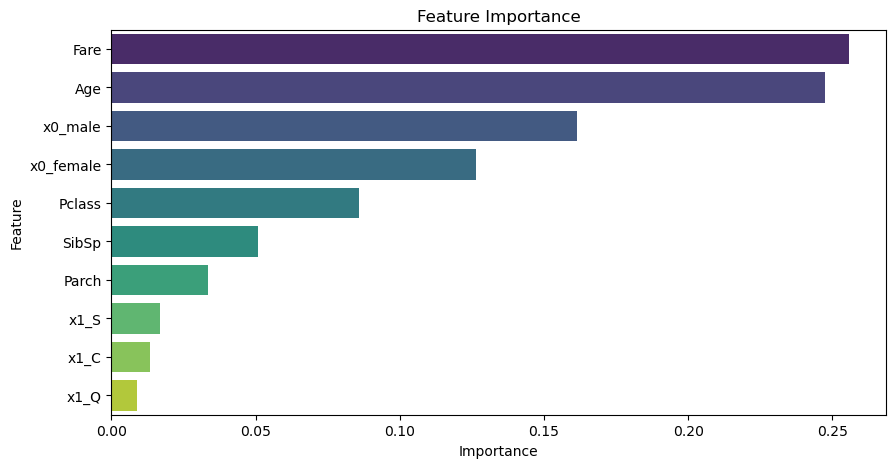

In [25]:
plt.figure(figsize=(10,5))
sns.barplot(x='Importance', 
            y='Feature',
            hue='Feature',
            data=feature_importance_df,
            palette='viridis',
           legend=False)
plt.title('Feature Importance')
plt.show()